# Machine Learning Project
## Final All-in-One Notebook for `poutcome` Classification

**Prepared by:** [Zaid Mayyalleh]
**Course:** Machine Learning  
**Dataset:** `bank.csv`

This notebook combines the full project in one place:

1. data exploration and preprocessing,
2. K-Means clustering,
3. supervised learning,
4. hyperparameter tuning,
5. final evaluation,
6. discussion and report answers.

## Assignment Coverage Map

The notebook is organized to match the assignment directly:

- **Section 1**: imports and setup
- **Section 2**: data loading and exploration
- **Section 3**: preprocessing for `poutcome`
- **Section 4**: K-Means clustering
- **Section 5**: supervised models
- **Section 6**: hyperparameter tuning with stratified k-fold
- **Section 7**: final evaluation and visualizations
- **Section 8**: discussion, challenges, and improvements

### 1. Imports and setup

I start by loading the libraries needed for analysis, visualization, preprocessing, clustering, model training, tuning, and evaluation.

In [1]:
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    adjusted_rand_score,
    classification_report,
    confusion_matrix,
    normalized_mutual_info_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

### 2. Load the dataset

In this section I load the bank marketing dataset and check its basic shape before moving to detailed analysis.

In [2]:
df = pd.read_csv("bank.csv")

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

display(df.head())

Rows: 11162
Columns: 17


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


### 3. Dataset structure and target distribution

Since the project target is `poutcome`, I inspect the feature types and the class distribution of this target first.

,data_type,non_null_count,unique_values
age,int64,11162,76
job,str,11162,12
marital,str,11162,3
education,str,11162,4
default,str,11162,2
balance,int64,11162,3805
housing,str,11162,2
loan,str,11162,2
contact,str,11162,3
day,int64,11162,31


Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']
Numerical features: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


,count,percentage
poutcome,,
unknown,8326,74.59
failure,1228,11.00
success,1071,9.60
other,537,4.81


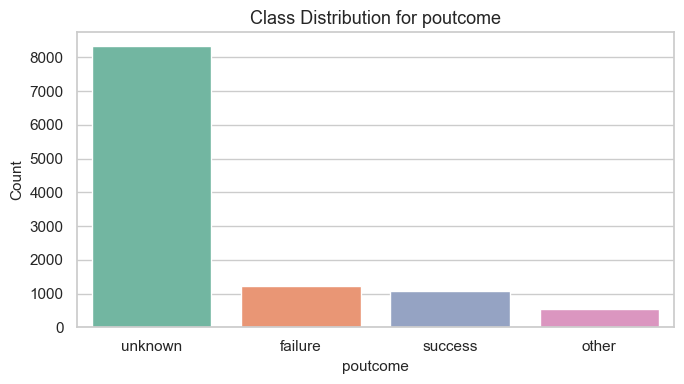

In [3]:
dataset_summary = pd.DataFrame(
    {
        "data_type": df.dtypes.astype(str),
        "non_null_count": df.notnull().sum(),
        "unique_values": df.nunique(),
    }
)
display(dataset_summary)

categorical_features = df.select_dtypes(include="object").columns.tolist()
numerical_features = df.select_dtypes(include=np.number).columns.tolist()

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

poutcome_summary = pd.DataFrame(
    {
        "count": df["poutcome"].value_counts(),
        "percentage": (df["poutcome"].value_counts(normalize=True) * 100).round(2),
    }
)
display(poutcome_summary)

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="poutcome", order=poutcome_summary.index, palette="Set2")
plt.title("Class Distribution for poutcome")
plt.xlabel("poutcome")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

The target is clearly imbalanced because the `unknown` class is much larger than the other classes. This means accuracy alone will not be enough to judge the models.

### 4. Data quality checks

Before preprocessing, I check missing values, duplicate rows, and the summary statistics of the numerical columns.

In [4]:
print(f"Duplicate rows: {df.duplicated().sum()}")

missing_table = pd.DataFrame(
    {
        "missing_values": df.isnull().sum(),
        "missing_percentage": (df.isnull().mean() * 100).round(2),
    }
)
display(missing_table)

display(df[numerical_features].describe().round(2))

Duplicate rows: 0


,missing_values,missing_percentage
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0
balance,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
day,0,0.0


,age,balance,day,duration,campaign,pdays,previous
count,11162.00,11162.00,11162.00,11162.00,11162.00,11162.00,11162.00
mean,41.23,1528.54,15.66,371.99,2.51,51.33,0.83
std,11.91,3225.41,8.42,347.13,2.72,108.76,2.29
min,18.00,-6847.00,1.00,2.00,1.00,-1.00,0.00
25%,32.00,122.00,8.00,138.00,1.00,-1.00,0.00
50%,39.00,550.00,15.00,255.00,2.00,-1.00,0.00
75%,49.00,1708.00,22.00,496.00,3.00,20.75,1.00
max,95.00,81204.00,31.00,3881.00,63.00,854.00,58.00


### 5. Exploratory analysis

I explore the numerical features and a few useful categorical features to understand the dataset better before modeling.

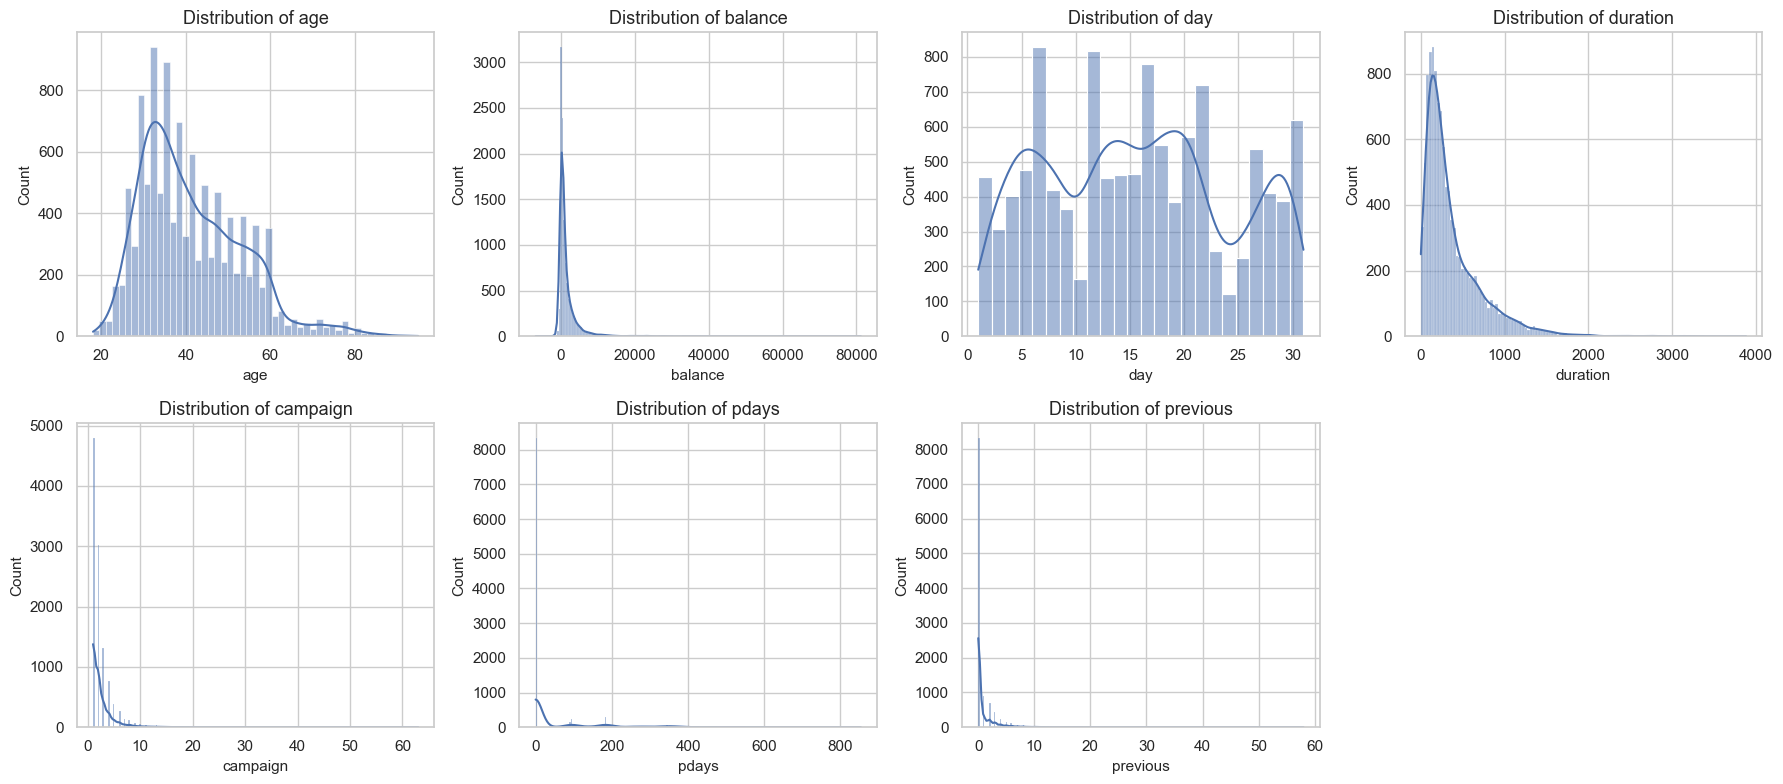

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for idx, column in enumerate(numerical_features):
    sns.histplot(df[column], kde=True, ax=axes[idx], color="#4c72b0")
    axes[idx].set_title(f"Distribution of {column}")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

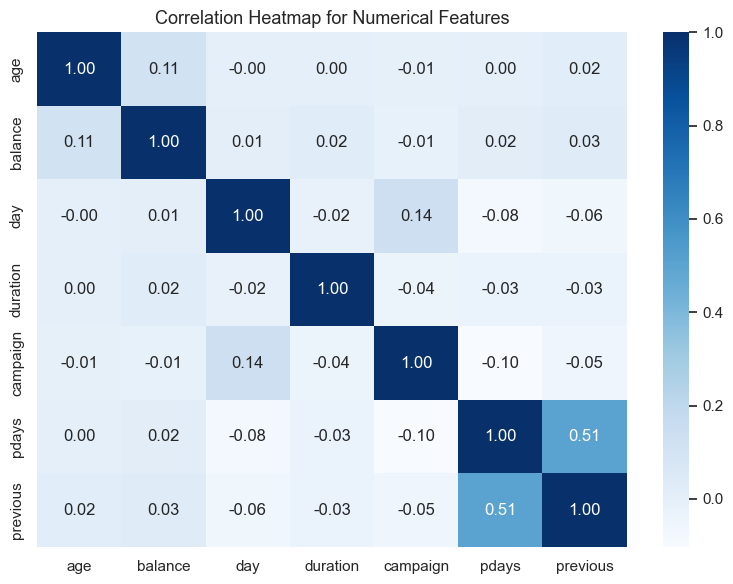

In [6]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[numerical_features].corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap for Numerical Features")
plt.tight_layout()
plt.show()

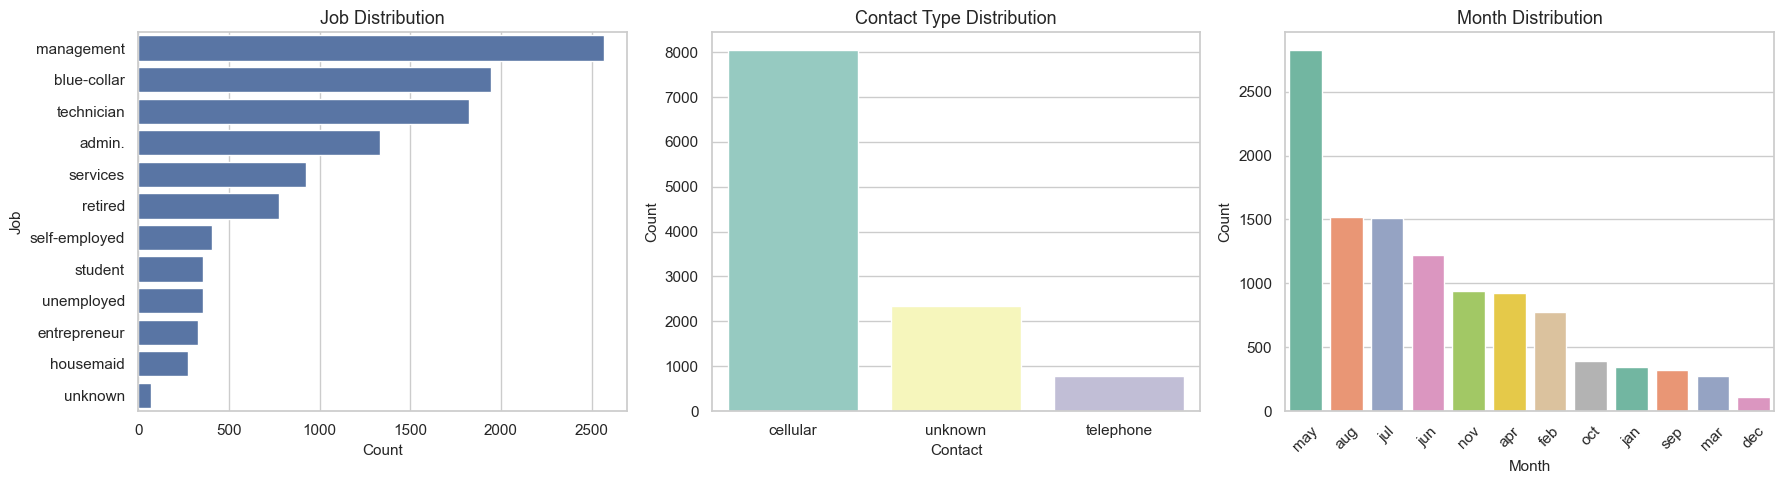

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, y="job", order=df["job"].value_counts().index, ax=axes[0], color="#4c72b0")
axes[0].set_title("Job Distribution")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Job")

sns.countplot(data=df, x="contact", order=df["contact"].value_counts().index, ax=axes[1], palette="Set3")
axes[1].set_title("Contact Type Distribution")
axes[1].set_xlabel("Contact")
axes[1].set_ylabel("Count")

sns.countplot(data=df, x="month", order=df["month"].value_counts().index, ax=axes[2], palette="Set2")
axes[2].set_title("Month Distribution")
axes[2].set_xlabel("Month")
axes[2].tick_params(axis="x", rotation=45)
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

### Short observations from EDA

A few points are clear from the exploration:

- the dataset is clean in terms of missing values and duplicates,
- the target is imbalanced,
- several numerical features are skewed and should be scaled,
- the data contains many categorical features, so encoding is necessary before modeling.

### 6. Preprocessing for supervised learning

The assignment asks to classify `poutcome`, so I use `poutcome` as the target and remove `deposit` from the input features.  
I apply one-hot encoding to categorical variables and standard scaling to the numerical columns.

In [8]:
X = df.drop(columns=["poutcome", "deposit"]).copy()
y = df["poutcome"].copy()

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=False)

print("Categorical input columns:", categorical_cols)
print("Numerical input columns:", numeric_cols)
print("Encoded feature count:", X_encoded.shape[1])

Categorical input columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month']
Numerical input columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Encoded feature count: 47


In [9]:
X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

scaler = StandardScaler()
X_train = X_train.copy()
X_test = X_test.copy()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)
class_names = list(label_encoder.classes_)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

class_mapping = pd.DataFrame(
    {"class_id": range(len(class_names)), "poutcome": class_names}
)
display(class_mapping)

Train shape: (8929, 47)
Test shape: (2233, 47)


,class_id,poutcome
0,0,failure
1,1,other
2,2,success
3,3,unknown


In [10]:
train_test_distribution = pd.DataFrame(
    {
        "full_dataset_%": (y.value_counts(normalize=True) * 100).round(2),
        "train_%": (y_train_raw.value_counts(normalize=True) * 100).round(2),
        "test_%": (y_test_raw.value_counts(normalize=True) * 100).round(2),
    }
).reindex(class_names)

display(train_test_distribution)

,full_dataset_%,train_%,test_%
poutcome,,,
failure,11.00,11.00,11.02
other,4.81,4.82,4.79
success,9.60,9.60,9.58
unknown,74.59,74.59,74.61


The train and test sets keep almost the same class percentages, which confirms that the stratified split worked correctly.

### 7. Unsupervised learning with K-Means

For K-Means, the assignment says to remove both `poutcome` and `deposit`.  
I prepare a separate feature matrix for clustering, scale it, and then test multiple values of `k` using the elbow method.

,k,inertia
0,2,110892.164516
1,3,103509.201531
2,4,97522.463819
3,5,91999.614663
4,6,87114.820131
5,7,82880.083206
6,8,79525.860460


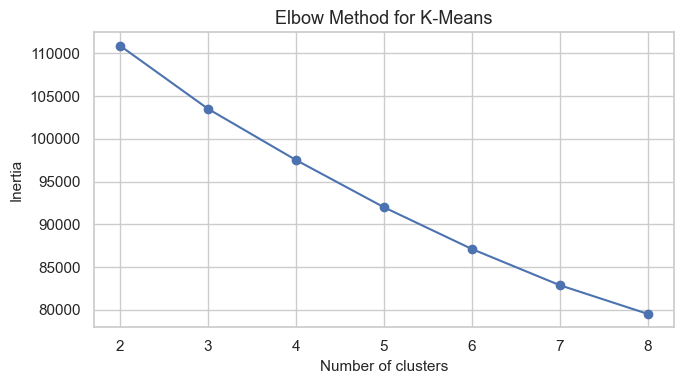

In [11]:
cluster_X = df.drop(columns=["poutcome", "deposit"]).copy()
cluster_cat_cols = cluster_X.select_dtypes(include="object").columns.tolist()
cluster_num_cols = cluster_X.select_dtypes(include=np.number).columns.tolist()

cluster_encoded = pd.get_dummies(cluster_X, columns=cluster_cat_cols, drop_first=False)
cluster_encoded[cluster_num_cols] = StandardScaler().fit_transform(
    cluster_encoded[cluster_num_cols]
)

inertias = []
k_values = list(range(2, 9))

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    kmeans.fit(cluster_encoded)
    inertias.append(kmeans.inertia_)

elbow_table = pd.DataFrame({"k": k_values, "inertia": inertias})
display(elbow_table)

plt.figure(figsize=(7, 4))
plt.plot(k_values, inertias, marker="o")
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.tight_layout()
plt.show()

In [12]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=20)
cluster_labels = kmeans_final.fit_predict(cluster_encoded)

ari = adjusted_rand_score(df["poutcome"], cluster_labels)
nmi = normalized_mutual_info_score(df["poutcome"], cluster_labels)

print(f"Adjusted Rand Index: {ari:.3f}")
print(f"Normalized Mutual Information: {nmi:.3f}")

cluster_vs_class = pd.crosstab(
    pd.Series(cluster_labels, name="cluster"),
    df["poutcome"],
)
display(cluster_vs_class)

Adjusted Rand Index: 0.308
Normalized Mutual Information: 0.338


poutcome,failure,other,success,unknown
cluster,,,,
0,142,67,270,2644
1,109,60,173,5215
2,3,2,1,466
3,974,408,627,1


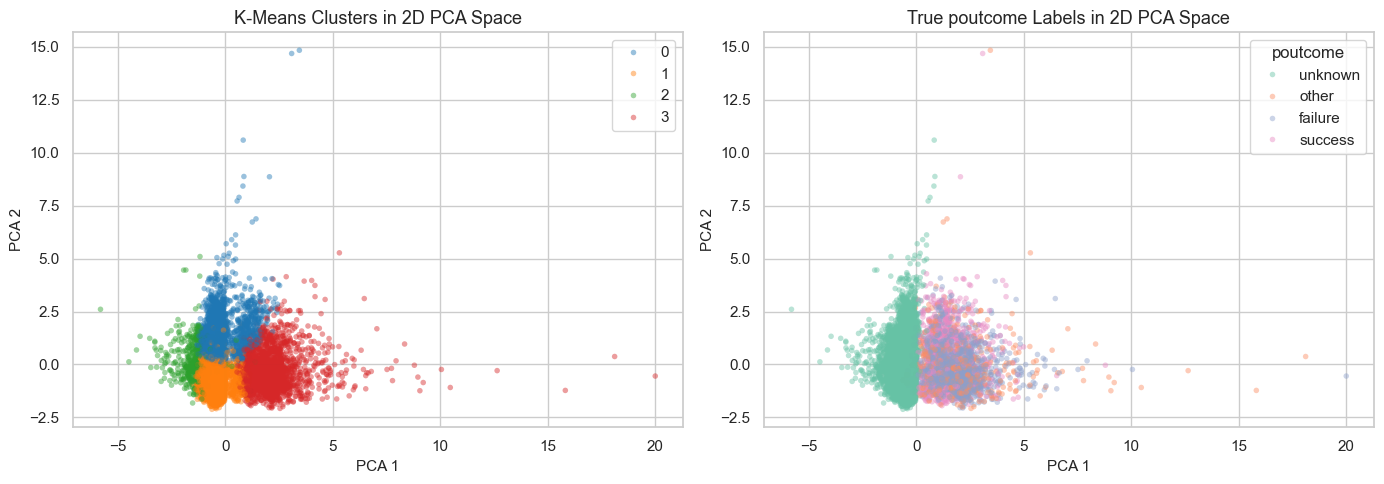

In [13]:
pca = PCA(n_components=2, random_state=42)
cluster_2d = pca.fit_transform(cluster_encoded)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    x=cluster_2d[:, 0],
    y=cluster_2d[:, 1],
    hue=cluster_labels,
    palette="tab10",
    s=16,
    alpha=0.45,
    linewidth=0,
    ax=axes[0],
)
axes[0].set_title("K-Means Clusters in 2D PCA Space")
axes[0].set_xlabel("PCA 1")
axes[0].set_ylabel("PCA 2")

sns.scatterplot(
    x=cluster_2d[:, 0],
    y=cluster_2d[:, 1],
    hue=df["poutcome"],
    palette="Set2",
    s=16,
    alpha=0.45,
    linewidth=0,
    ax=axes[1],
)
axes[1].set_title("True poutcome Labels in 2D PCA Space")
axes[1].set_xlabel("PCA 1")
axes[1].set_ylabel("PCA 2")

plt.tight_layout()
plt.show()

### K-Means discussion

The elbow method shows a gradual decrease in inertia, but not a very sharp bend.  
I used `k = 4` to match the number of real target classes. The clustering scores are not strong, which shows that K-Means is limited here because it is unsupervised and the target classes are imbalanced.

### 8. Supervised learning models

To classify `poutcome`, I use two models:

- **MLPClassifier** as the neural network model
- **GradientBoostingClassifier** as the ensemble model

I first train simple default versions to get baseline results before tuning.

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline_models = {
    "MLP default": MLPClassifier(
        random_state=42,
        max_iter=250,
        early_stopping=True,
        n_iter_no_change=15,
    ),
    "Gradient Boosting default": GradientBoostingClassifier(random_state=42),
}

baseline_rows = []

for model_name, model in baseline_models.items():
    model.fit(X_train, y_train)
    baseline_pred = model.predict(X_test)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_test,
        baseline_pred,
        average="macro",
        zero_division=0,
    )

    baseline_rows.append(
        {
            "model": model_name,
            "test_accuracy": accuracy_score(y_test, baseline_pred),
            "macro_precision": macro_p,
            "macro_recall": macro_r,
            "macro_f1": macro_f1,
        }
    )

baseline_results = pd.DataFrame(baseline_rows).sort_values(
    by="test_accuracy",
    ascending=False,
)
display(baseline_results.round(4))

,model,test_accuracy,macro_precision,macro_recall,macro_f1
1,Gradient Boosting default,0.9046,0.6467,0.6463,0.6293
0,MLP default,0.8957,0.6647,0.6252,0.6147


### 9. Hyperparameter tuning with stratified k-fold cross validation

I use `GridSearchCV` with `f1_macro` because the class distribution is imbalanced.  
This helps me give more attention to the smaller classes instead of letting the largest class dominate the score.

In [15]:
mlp = MLPClassifier(
    random_state=42,
    max_iter=250,
    early_stopping=True,
    n_iter_no_change=15,
)

mlp_param_grid = {
    "hidden_layer_sizes": [(64,), (128,), (64, 32)],
    "learning_rate_init": [0.001, 0.01],
    "batch_size": [32, 64],
}

mlp_search = GridSearchCV(
    estimator=mlp,
    param_grid=mlp_param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
)

mlp_search.fit(X_train, y_train)

print("Best MLP parameters:", mlp_search.best_params_)
print(f"Best MLP CV score: {mlp_search.best_score_:.4f}")

Best MLP parameters: {'batch_size': 32, 'hidden_layer_sizes': (128,), 'learning_rate_init': 0.01}
Best MLP CV score: 0.5810


In [16]:
gb = GradientBoostingClassifier(random_state=42)

gb_param_grid = {
    "n_estimators": [100, 150],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3],
}

gb_search = GridSearchCV(
    estimator=gb,
    param_grid=gb_param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
)

gb_search.fit(X_train, y_train)

print("Best Gradient Boosting parameters:", gb_search.best_params_)
print(f"Best Gradient Boosting CV score: {gb_search.best_score_:.4f}")

Best Gradient Boosting parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150}
Best Gradient Boosting CV score: 0.6125


In [17]:
mlp_tuning_table = (
    pd.DataFrame(mlp_search.cv_results_)[
        ["params", "mean_test_score", "std_test_score", "rank_test_score"]
    ]
    .sort_values(by=["rank_test_score", "mean_test_score"])
    .head(5)
)

gb_tuning_table = (
    pd.DataFrame(gb_search.cv_results_)[
        ["params", "mean_test_score", "std_test_score", "rank_test_score"]
    ]
    .sort_values(by=["rank_test_score", "mean_test_score"])
    .head(5)
)

print("Top MLP parameter combinations")
display(mlp_tuning_table)

print("Top Gradient Boosting parameter combinations")
display(gb_tuning_table)

Top MLP parameter combinations


,params,mean_test_score,std_test_score,rank_test_score
3,"{'batch_size': 32, 'hidden_layer_sizes': (128,...",0.581034,0.015582,1
8,"{'batch_size': 64, 'hidden_layer_sizes': (128,...",0.580704,0.020081,2
9,"{'batch_size': 64, 'hidden_layer_sizes': (128,...",0.580340,0.006121,3
10,"{'batch_size': 64, 'hidden_layer_sizes': (64, ...",0.577890,0.016489,4
2,"{'batch_size': 32, 'hidden_layer_sizes': (128,...",0.576107,0.013998,5


Top Gradient Boosting parameter combinations


,params,mean_test_score,std_test_score,rank_test_score
7,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.612520,0.010508,1
3,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.612378,0.012752,2
2,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.609923,0.014719,3
4,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti...",0.609032,0.015957,4
5,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti...",0.608501,0.016078,5


### 10. Final evaluation on train and test sets

In this section I evaluate the best tuned model from each algorithm, compare train vs test performance, and inspect the class-level metrics.

In [18]:
def evaluate_model(model_name, model, X_train, y_train, X_test, y_test, class_names):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)

    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_test,
        test_pred,
        average="macro",
        zero_division=0,
    )
    micro_p, micro_r, micro_f1, _ = precision_recall_fscore_support(
        y_test,
        test_pred,
        average="micro",
        zero_division=0,
    )

    report_df = pd.DataFrame(
        classification_report(
            y_test,
            test_pred,
            target_names=class_names,
            output_dict=True,
            zero_division=0,
        )
    ).T
    report_df.loc["micro avg"] = [micro_p, micro_r, micro_f1, len(y_test)]

    summary = {
        "model": model_name,
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy,
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "micro_precision": micro_p,
        "micro_recall": micro_r,
        "micro_f1": micro_f1,
    }

    cm = confusion_matrix(y_test, test_pred)
    return summary, report_df, cm


tuned_models = {
    "MLP tuned": mlp_search.best_estimator_,
    "Gradient Boosting tuned": gb_search.best_estimator_,
}

evaluation_rows = []
detailed_reports = {}
confusion_matrices = {}

for model_name, model in tuned_models.items():
    summary, report_df, cm = evaluate_model(
        model_name,
        model,
        X_train,
        y_train,
        X_test,
        y_test,
        class_names,
    )
    evaluation_rows.append(summary)
    detailed_reports[model_name] = report_df
    confusion_matrices[model_name] = cm

comparison_df = pd.DataFrame(evaluation_rows).sort_values(
    by="test_accuracy",
    ascending=False,
)
display(comparison_df.round(4))

,model,train_accuracy,test_accuracy,macro_precision,macro_recall,macro_f1,micro_precision,micro_recall,micro_f1
1,Gradient Boosting tuned,0.9346,0.9060,0.6500,0.6492,0.6323,0.9060,0.9060,0.9060
0,MLP tuned,0.9027,0.8948,0.6461,0.6264,0.6177,0.8948,0.8948,0.8948


In [19]:
for model_name, report_df in detailed_reports.items():
    print(model_name)
    display(
        report_df.loc[
            class_names + ["macro avg", "weighted avg", "micro avg"]
        ].round(4)
    )

MLP tuned


,precision,recall,f1-score,support
failure,0.5932,0.7114,0.6470,246.0
other,0.3824,0.1215,0.1844,107.0
success,0.6102,0.6729,0.6400,214.0
unknown,0.9988,1.0000,0.9994,1666.0
macro avg,0.6461,0.6264,0.6177,2233.0
weighted avg,0.8873,0.8948,0.8871,2233.0
micro avg,0.8948,0.8948,0.8948,2233.0


Gradient Boosting tuned


,precision,recall,f1-score,support
failure,0.6318,0.7602,0.6900,246.0
other,0.3000,0.0841,0.1314,107.0
success,0.6680,0.7523,0.7077,214.0
unknown,1.0000,1.0000,1.0000,1666.0
macro avg,0.6500,0.6492,0.6323,2233.0
weighted avg,0.8941,0.9060,0.8962,2233.0
micro avg,0.9060,0.9060,0.9060,2233.0


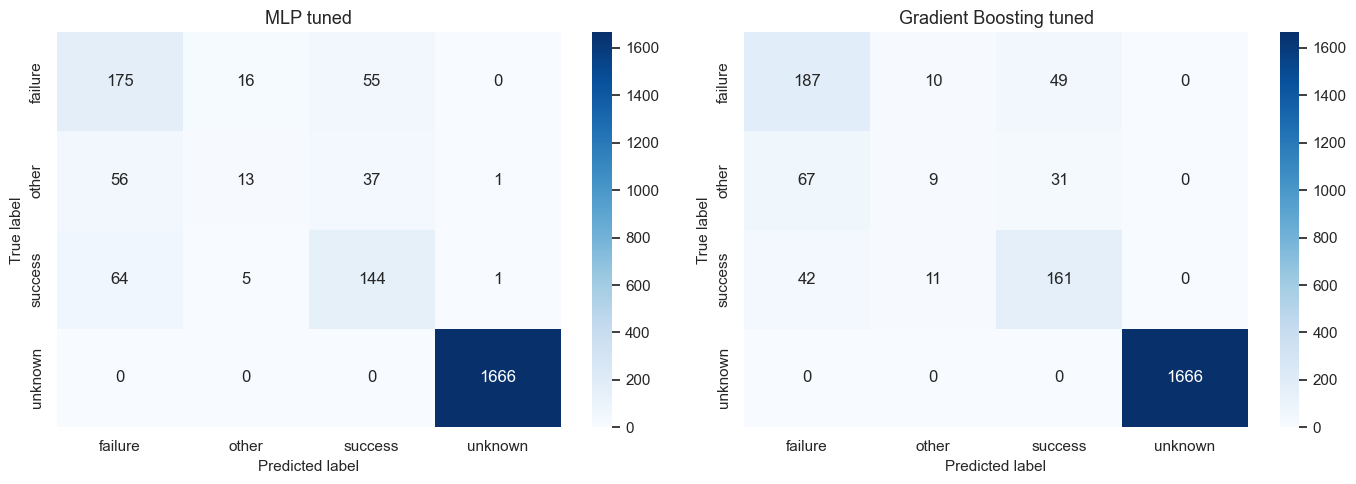

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (model_name, cm) in zip(axes, confusion_matrices.items()):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
    )
    ax.set_title(model_name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

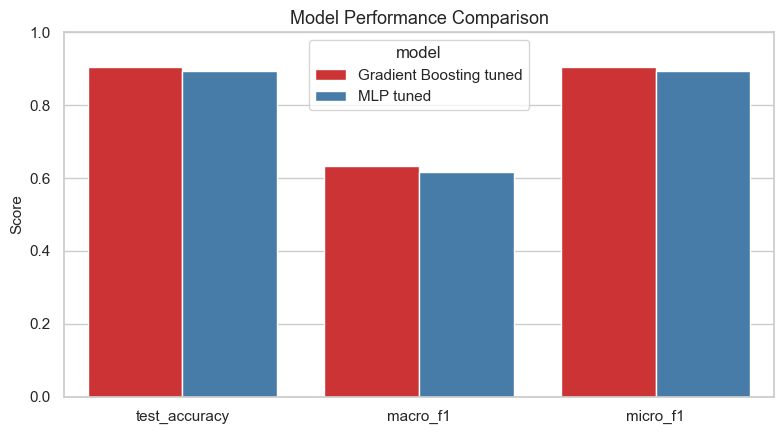

In [21]:
plot_df = comparison_df.melt(
    id_vars="model",
    value_vars=["test_accuracy", "macro_f1", "micro_f1"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(8, 4.5))
sns.barplot(data=plot_df, x="metric", y="score", hue="model", palette="Set1")
plt.ylim(0, 1)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("")
plt.tight_layout()
plt.show()

,feature,importance
5,pdays,0.673106
6,previous,0.250182
3,duration,0.016400
29,housing_yes,0.009291
1,balance,0.009161
0,age,0.008233
2,day,0.007038
44,month_nov,0.004501
28,housing_no,0.004074
4,campaign,0.002850


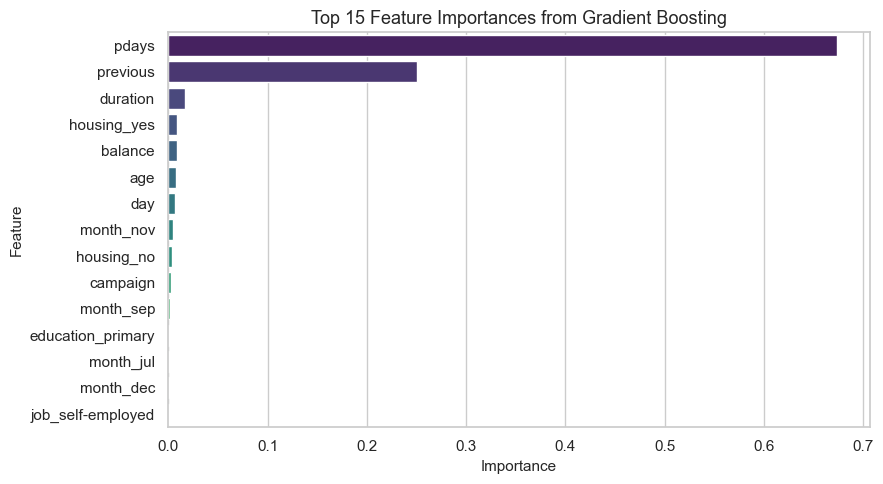

In [22]:
gb_best = gb_search.best_estimator_
feature_importance = (
    pd.DataFrame(
        {
            "feature": X_train.columns,
            "importance": gb_best.feature_importances_,
        }
    )
    .sort_values(by="importance", ascending=False)
    .head(15)
)

display(feature_importance)

plt.figure(figsize=(9, 5))
sns.barplot(data=feature_importance, x="importance", y="feature", palette="viridis")
plt.title("Top 15 Feature Importances from Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### 11. Direct answers for the report section

The assignment also asks for a written discussion.  
Instead of keeping it in a separate file, I answer the report questions directly here in the same notebook.

In [23]:
best_model_row = comparison_df.iloc[0]
best_model_name = best_model_row["model"]

print(f"Best model: {best_model_name}")
print(f"Test accuracy: {best_model_row['test_accuracy']:.4f}")
print(f"Macro F1-score: {best_model_row['macro_f1']:.4f}")
print()

print("Effect of tuning")
print(
    f"MLP: baseline macro F1 = {baseline_results.loc[baseline_results['model'] == 'MLP default', 'macro_f1'].iloc[0]:.4f}, "
    f"tuned macro F1 = {comparison_df.loc[comparison_df['model'] == 'MLP tuned', 'macro_f1'].iloc[0]:.4f}"
)
print(
    f"Gradient Boosting: baseline macro F1 = {baseline_results.loc[baseline_results['model'] == 'Gradient Boosting default', 'macro_f1'].iloc[0]:.4f}, "
    f"tuned macro F1 = {comparison_df.loc[comparison_df['model'] == 'Gradient Boosting tuned', 'macro_f1'].iloc[0]:.4f}"
)

Best model: Gradient Boosting tuned
Test accuracy: 0.9060
Macro F1-score: 0.6323

Effect of tuning
MLP: baseline macro F1 = 0.6147, tuned macro F1 = 0.6177
Gradient Boosting: baseline macro F1 = 0.6293, tuned macro F1 = 0.6323


### 12. Final discussion

**Which model performed best?**  
The best model was the tuned Gradient Boosting model. It achieved the highest test accuracy and the strongest macro F1-score among the tested supervised models.

**How did tuning affect the models?**  
Tuning improved Gradient Boosting slightly and gave only a small improvement for MLP. This means the default settings were already reasonable, but some gains were still possible through grid search.

**What do the confusion matrices show?**  
The `unknown` class was the easiest one because it had the most samples and was classified very well by both tuned models.  
The `other` class was the hardest one and was often confused with `failure` and `success`.

**What challenges appeared in the project?**

- strong class imbalance,
- weak recall for smaller classes,
- limited match between K-Means clusters and true labels,
- tuning cost in terms of runtime.

**What can be improved later?**

- try class balancing methods,
- test more ensemble models such as Random Forest or XGBoost,
- expand the tuning grid,
- try feature selection and more advanced feature engineering.

## Final conclusion

This notebook completes the full machine learning workflow for classifying `poutcome`:

- data exploration and preprocessing,
- unsupervised clustering,
- supervised classification,
- tuning and evaluation,
- written discussion and final conclusions.

Overall, supervised learning performed much better than unsupervised clustering for this task, and the tuned Gradient Boosting model gave the best final result in this project.